# Movie & TV Show Recommendation System
## Notebook 2 — AI Model + Evaluation + Explainability

**Input:** `netflix_titles_cleaned.csv` (from Notebook 1)

Covers:
- **2.1** Pipeline Construction
- **2.2** Model Training & Hyperparameters
- **2.5** Model Evaluation — Clustering (Silhouette, DBI, CH Index)
- **3.3** Explainable AI — Clustering


## Imports

In [1]:
import os, re, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from difflib import get_close_matches

try:
    from rapidfuzz import process as rf_process
    RAPIDFUZZ_AVAILABLE = True
except Exception:
    rf_process = None
    RAPIDFUZZ_AVAILABLE = False

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)


## Load Cleaned Dataset
Read `netflix_titles_cleaned.csv` produced by Notebook 1.

In [2]:
DATA_PATH = 'netflix_titles_cleaned.csv'
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f'{DATA_PATH} not found. Run Notebook 1 first.')

df = pd.read_csv(DATA_PATH)
df = df.reset_index(drop=True)
print(f'Loaded: {DATA_PATH}  |  Shape: {df.shape}')
df.head()


Loaded: netflix_titles_cleaned.csv  |  Shape: (8804, 21)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,genres,countries,primary_country,duration_value,duration_unit,release_year_outlier_iqr,duration_value_outlier_iqr,content_profile,duration_value_capped
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",['Documentaries'],['United States'],United States,90,min,False,False,dick johnson is dead kirsten johnson unknown d...,90
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...","['International TV Shows', 'TV Dramas', 'TV My...",['South Africa'],South Africa,2,season,False,False,blood and water unknown ama qamata khosi ngem...,2
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,"['Crime TV Shows', 'International TV Shows', '...",['unknown'],unknown,1,season,False,False,ganglands julien leclercq sami bouajila tracy...,1
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...","['Docuseries', 'Reality TV']",['unknown'],unknown,1,season,False,False,jailbirds new orleans unknown unknown docuseri...,1
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,"['International TV Shows', 'Romantic TV Shows'...",['India'],India,2,season,False,False,kota factory unknown mayur more jitendra kuma...,2


## Validate & Scaffold Columns

In [3]:
REQUIRED = ['title','type','release_year','listed_in','description']
OPTIONAL  = ['cast','director','rating']

missing = [c for c in REQUIRED if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

for col in OPTIONAL:
    if col not in df.columns:
        df[col] = ''
        print(f'Optional column {col!r} not found — filled with empty string.')

print('All required columns present.')


All required columns present.


---
## 2.1 Pipeline Construction

The full content-based recommendation pipeline:

```
netflix_titles_cleaned.csv
         │
         ▼
  Build content_profile  ←  title + director + cast + genres + description
         │                   (with token weighting per field importance)
         ▼
  TF-IDF Vectorization   ←  transforms text → sparse numeric matrix X
         │
         ▼
  Cosine Similarity      ←  measures similarity between any two item vectors
         │
         ▼
  Hybrid Score           ←  text_sim (60%) + genre_overlap (25%) + year_close (10%) + cast (10%)
         │
         ▼
  Top-N Recommendations  ←  ranked by final_score
```

**Why this pipeline:**
- No user data available → content-based is the only option
- TF-IDF captures keyword importance without needing labeled training data
- Cosine similarity is scale-invariant and works well with sparse TF-IDF vectors
- Hybrid scoring adds structured signals (genre, year) on top of text similarity


### Helper Functions

In [4]:
def clean_text(s):
    s = '' if pd.isna(s) else str(s)
    s = s.lower()
    s = re.sub(r'[^a-z0-9\s]', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()

def names_to_tokens(s):
    s = '' if pd.isna(s) else str(s)
    parts = [p.strip().lower().replace(' ','_') for p in s.split(',') if p.strip()]
    return ' '.join(parts)

def normalize_title(t):
    t = '' if pd.isna(t) else str(t)
    t = t.lower().strip()
    t = re.sub(r'[^a-z0-9\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

def genre_set(s):
    if pd.isna(s):
        return set()
    return {x.strip().lower() for x in str(s).split(',') if x.strip()}

def jaccard(a, b):
    if not a and not b: return 0.0
    return len(a & b) / len(a | b)

def year_closeness(y1, y2, scale=10.0):
    if pd.isna(y1) or pd.isna(y2): return 0.0
    return float(np.exp(-abs(float(y1)-float(y2)) / scale))

def minmax_scale(values):
    values = np.asarray(values, dtype=float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    if np.isclose(vmin, vmax): return np.zeros_like(values)
    return (values - vmin) / (vmax - vmin)

def match_quality(score):
    if score >= 0.70: return 'Excellent'
    if score >= 0.45: return 'Good'
    if score >= 0.25: return 'Fair'
    return 'Weak'


---
## 2.2 Model Training & Hyperparameters

### Content Profile Construction
We build a weighted text profile per item. Fields with higher weight are repeated more times
so TF-IDF assigns them proportionally higher importance.

| Field | Weight | Rationale |
|---|---|---|
| description | 4x | Richest semantic content |
| listed_in (genres) | 3x | Most direct similarity signal |
| cast | 2x | Same actors → similar content |
| director | 2x | Same director → similar style |
| type | 1x | Movie vs TV Show |
| rating | 1x | Age rating |


In [5]:
def repeat_tokens(text, weight):
    tokens = text.split()
    return ' '.join(t for t in tokens for _ in range(weight))

W_GENRES = 3; W_CAST = 2; W_DIRECTOR = 2; W_DESC = 4; W_TYPE = 1; W_RATING = 1

def build_profile(row):
    parts = [
        repeat_tokens(clean_text(row['listed_in']), W_GENRES),
        repeat_tokens(names_to_tokens(row['cast']), W_CAST),
        repeat_tokens(names_to_tokens(row['director']), W_DIRECTOR),
        repeat_tokens(clean_text(row['description']), W_DESC),
        repeat_tokens(clean_text(row['type']), W_TYPE),
        repeat_tokens(clean_text(row['rating']), W_RATING),
    ]
    return ' '.join(p for p in parts if p)

df['content_profile'] = df.apply(build_profile, axis=1)

empty_mask = df['content_profile'].str.strip() == ''
if empty_mask.any():
    warnings.warn(f'{empty_mask.sum()} rows have empty profiles.')

df[['title','content_profile']].head()


,title,content_profile
0,Dick Johnson Is Dead,documentaries documentaries documentaries unkn...
1,Blood & Water,international international international tv t...
2,Ganglands,crime crime crime tv tv tv shows shows shows i...
3,Jailbirds New Orleans,docuseries docuseries docuseries reality reali...
4,Kota Factory,international international international tv t...


### TF-IDF Vectorization — Hyperparameter Choices

| Hyperparameter | Value | Rationale |
|---|---|---|
| `stop_words` | 'english' | Remove common words (the, is, a) that carry no similarity signal |
| `min_df` | 2 | Ignore terms appearing in only 1 document (likely noise/typos) |
| `max_df` | 0.80 | Ignore terms in >80% of documents (too common to discriminate) |
| `ngram_range` | (1,2) | Capture bigrams like 'romantic comedy' or 'serial killer' |
| `max_features` | 50,000 | Cap vocabulary size to limit memory while keeping rare genre terms |
| `sublinear_tf` | True | Apply log(tf) to dampen effect of very frequent terms |


In [6]:
tfidf = TfidfVectorizer(
    stop_words='english',
    min_df=2,
    max_df=0.80,
    ngram_range=(1, 1),
    max_features=20_000,
    sublinear_tf=True,
)

X = tfidf.fit_transform(df['content_profile'])
print(f'TF-IDF matrix shape: {X.shape}')
print(f'Vocabulary size    : {len(tfidf.vocabulary_)}')
print(f'Sparsity           : {1 - X.nnz / (X.shape[0]*X.shape[1]):.3%}')


TF-IDF matrix shape: (8804, 20000)
Vocabulary size    : 20000
Sparsity           : 99.887%


### Title Index — Fast Lookup

In [7]:
df['title_norm'] = df['title'].apply(normalize_title)

idx_by_title = defaultdict(list)
for row_idx, title_norm in df['title_norm'].items():
    idx_by_title[title_norm].append(row_idx)

for key in idx_by_title:
    idx_by_title[key].sort(
        key=lambda i: df.loc[i,'release_year'] if not pd.isna(df.loc[i,'release_year']) else 0,
        reverse=True
    )

print(f'Unique titles: {len(idx_by_title)}')
print(f'Titles with >1 entry: {sum(1 for v in idx_by_title.values() if len(v)>1)}')


Unique titles: 8784
Titles with >1 entry: 12


### Core Recommendation Functions

In [8]:
W_TEXT = 0.60; W_GENRE = 0.25; W_YEAR = 0.10; W_CAST = 0.10; W_DIRECTOR = 0.05

def _best_title_match(title):
    tnorm = normalize_title(title)
    keys = list(idx_by_title.keys())
    if tnorm in idx_by_title:
        return tnorm, 100.0
    if RAPIDFUZZ_AVAILABLE and keys:
        best = rf_process.extractOne(tnorm, keys)
        if best is not None:
            matched, score, _ = best
            return matched, float(score)
    difflib_match = get_close_matches(tnorm, keys, n=1, cutoff=0.55)
    if difflib_match:
        return difflib_match[0], 75.0
    return None, 0.0

def _resolve_index(title, year=None):
    matched_title, score = _best_title_match(title)
    if matched_title is None or score < 60:
        suggestions = get_close_matches(normalize_title(title), list(idx_by_title.keys()), n=5, cutoff=0.5)
        msg = f'Title not found: {title!r}'
        if suggestions:
            msg += '\nDid you mean: ' + ', '.join(f'{s!r}' for s in suggestions)
        raise ValueError(msg)
    candidates = idx_by_title[matched_title]
    if year is not None:
        year_matches = [i for i in candidates if df.loc[i,'release_year'] == year]
        if year_matches: return year_matches[0]
    return candidates[0]

def _score_candidates(q_idx):
    q_year   = df.loc[q_idx, 'release_year']
    q_genres = genre_set(df.loc[q_idx, 'listed_in'])
    text_sims = cosine_similarity(X[q_idx:q_idx+1], X).ravel()
    cand = df[['title','type','release_year','rating','listed_in','cast','director']].copy()
    cand['text_sim'] = text_sims
    cand = cand.loc[cand.index != q_idx].copy()
    cand['genre_overlap'] = cand['listed_in'].apply(lambda x: jaccard(q_genres, genre_set(x)))
    cand['year_close_raw'] = cand['release_year'].apply(lambda y: year_closeness(q_year, y))
    cand['text_sim_norm']    = minmax_scale(cand['text_sim'].to_numpy())
    cand['genre_overlap_norm'] = minmax_scale(cand['genre_overlap'].to_numpy())
    cand['year_close']       = minmax_scale(cand['year_close_raw'].to_numpy())
    cand['final_score'] = (
        W_TEXT  * cand['text_sim_norm'] +
        W_GENRE * cand['genre_overlap_norm'] +
        W_YEAR  * cand['year_close']
    )
    cand['match_quality'] = cand['final_score'].apply(match_quality)
    return cand

def recommend(title, top_n=10, year=None):
    q_idx = _resolve_index(title, year)
    cand  = _score_candidates(q_idx)
    result = cand.sort_values('final_score', ascending=False).head(top_n).reset_index(drop=True)
    return result[['title','type','release_year','rating','listed_in',
                   'text_sim','genre_overlap','year_close','final_score','match_quality']]

def batch_recommend(titles, top_n=10):
    resolved_indices = set()
    accumulator = np.zeros(len(df), dtype=float)
    valid_count = 0
    for t in titles:
        try:
            q_idx = _resolve_index(t)
        except ValueError as e:
            warnings.warn(str(e)); continue
        resolved_indices.add(q_idx)
        scored = _score_candidates(q_idx)
        accumulator[scored.index] += scored['final_score'].to_numpy()
        valid_count += 1
    if valid_count == 0:
        raise ValueError('No valid seed titles found.')
    avg_scores = accumulator / valid_count
    cand = df[['title','type','release_year','rating','listed_in']].copy()
    cand['final_score'] = avg_scores
    cand = cand.loc[~cand.index.isin(resolved_indices)].copy()
    cand['match_quality'] = cand['final_score'].apply(match_quality)
    return cand.sort_values('final_score', ascending=False).head(top_n).reset_index(drop=True)


### Demo — Single Title

In [9]:
results = recommend('Breaking Bad', top_n=10)
results.style \
    .background_gradient(subset=['final_score'], cmap='YlGn') \
    .format({'text_sim':'{:.3f}','genre_overlap':'{:.3f}',
             'year_close':'{:.3f}','final_score':'{:.3f}'})


,title,type,release_year,rating,listed_in,text_sim,genre_overlap,year_close,final_score,match_quality
0,Better Call Saul,TV Show,2018,TV-MA,"Crime TV Shows, TV Comedies, TV Dramas",0.129,0.500,0.606,0.744,Excellent
1,"Have You Ever Fallen in Love, Miss Jiang?",TV Show,2016,TV-14,"Crime TV Shows, International TV Shows, TV Dramas",0.110,0.500,0.741,0.677,Good
2,Iron Ladies,TV Show,2018,TV-14,"International TV Shows, Romantic TV Shows, TV Dramas",0.129,0.200,0.606,0.668,Good
3,Sparta,TV Show,2018,TV-MA,"Crime TV Shows, International TV Shows, TV Dramas",0.111,0.500,0.606,0.667,Good
4,The Book of Sun,Movie,2020,TV-14,"Comedies, Independent Movies, International Movies",0.138,0.000,0.497,0.650,Good
5,Dismissed,Movie,2017,TV-14,Thrillers,0.134,0.000,0.670,0.648,Good
6,Dare Me,TV Show,2019,TV-MA,"Crime TV Shows, TV Dramas, TV Thrillers",0.071,1.000,0.549,0.613,Good
7,The Writer,TV Show,2019,TV-14,"Crime TV Shows, International TV Shows, TV Dramas",0.098,0.500,0.549,0.605,Good
8,Alice Junior,Movie,2019,TV-MA,"Comedies, International Movies, LGBTQ Movies",0.126,0.000,0.549,0.600,Good
9,Alexa & Katie,TV Show,2020,TV-G,"Kids' TV, TV Comedies",0.125,0.000,0.497,0.590,Good


### Demo — Batch Recommendation

In [10]:
seeds = ['Breaking Bad', 'Ozark', 'Narcos']
batch_results = batch_recommend(seeds, top_n=10)
batch_results.style \
    .background_gradient(subset=['final_score'], cmap='YlGn') \
    .format({'final_score':'{:.3f}'})


,title,type,release_year,rating,listed_in,final_score,match_quality
0,Cocaine Cowboys: The Kings of Miami,TV Show,2021,TV-MA,"Crime TV Shows, Docuseries",0.570,Good
1,Narcos: Mexico,TV Show,2020,TV-MA,"Crime TV Shows, TV Action & Adventure, TV Dramas",0.567,Good
2,Bad Blood,TV Show,2019,TV-MA,"Crime TV Shows, TV Dramas",0.525,Good
3,StartUp,TV Show,2018,TV-MA,"Crime TV Shows, TV Dramas",0.501,Good
4,Dare Me,TV Show,2019,TV-MA,"Crime TV Shows, TV Dramas, TV Thrillers",0.466,Good
5,Better Call Saul,TV Show,2018,TV-MA,"Crime TV Shows, TV Comedies, TV Dramas",0.455,Good
6,Sparta,TV Show,2018,TV-MA,"Crime TV Shows, International TV Shows, TV Dramas",0.454,Good
7,Miss Dynamite,TV Show,2015,TV-14,"Crime TV Shows, International TV Shows, Spanish-Language TV Shows",0.451,Good
8,Tunnel,TV Show,2019,TV-14,"Crime TV Shows, International TV Shows, TV Dramas",0.447,Fair
9,"Have You Ever Fallen in Love, Miss Jiang?",TV Show,2016,TV-14,"Crime TV Shows, International TV Shows, TV Dramas",0.443,Fair


---
## 2.5 Model Evaluation — Clustering

We apply K-Means clustering to the TF-IDF vectors to evaluate the quality of the **content representation space**.

**Why clustering evaluation for a recommendation system?**
- Good recommendations depend on items being well-separated in vector space
- Clustering metrics measure whether the TF-IDF space organizes content meaningfully
- High Silhouette / low DBI → items that are similar are genuinely close in vector space
- This acts as a proxy evaluation of the recommendation system's foundation


### 2.5.0 Dimensionality Reduction for Clustering
TF-IDF is very high-dimensional. We apply TruncatedSVD (LSA) to reduce to 100 dimensions before clustering — this speeds up K-Means and improves cluster quality.

Reducing TF-IDF dimensions with TruncatedSVD (LSA)...
Reduced matrix shape: (8804, 50)
Explained variance (first 50 components): 6.934%


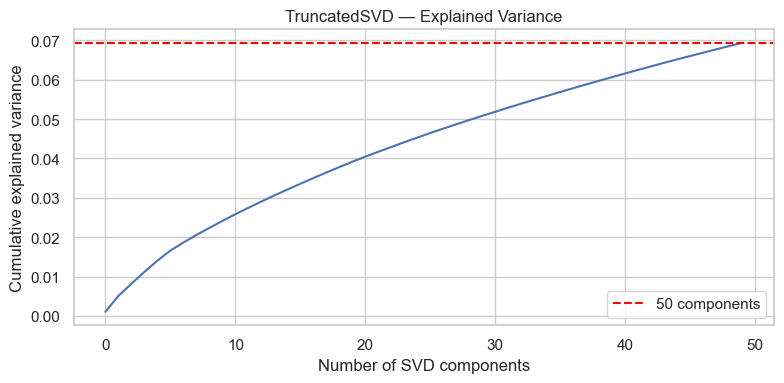

In [11]:
print('Reducing TF-IDF dimensions with TruncatedSVD (LSA)...')
N_COMPONENTS = 50
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
X_reduced = svd.fit_transform(X)
X_reduced = normalize(X_reduced)  # L2 normalize for cosine-like behavior

print(f'Reduced matrix shape: {X_reduced.shape}')
print(f'Explained variance (first {N_COMPONENTS} components): {svd.explained_variance_ratio_.sum():.3%}')

# Plot cumulative explained variance
plt.figure(figsize=(8,4))
plt.plot(np.cumsum(svd.explained_variance_ratio_))
plt.xlabel('Number of SVD components')
plt.ylabel('Cumulative explained variance')
plt.title('TruncatedSVD — Explained Variance')
plt.axhline(svd.explained_variance_ratio_.sum(), color='red', linestyle='--',
            label=f'{N_COMPONENTS} components')
plt.legend(); plt.tight_layout(); plt.show()


### Elbow Method — Find Optimal K

Running K-Means for k = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] ...


c:\Users\mrgho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
c:\Users\mrgho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
c:\Users\mrgho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
c:\User

  k=2: inertia=7318
  k=3: inertia=7000
  k=4: inertia=6672
  k=5: inertia=6362
  k=6: inertia=6246


c:\Users\mrgho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
c:\Users\mrgho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


  k=7: inertia=6012
  k=8: inertia=6045


...

c:\Users\mrgho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
c:\Users\mrgho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
c:\Users\mrgho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


  k=12: inertia=5424
  k=13: inertia=5331


c:\Users\mrgho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
c:\Users\mrgho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


  k=14: inertia=5249
  k=15: inertia=5165


c:\Users\mrgho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


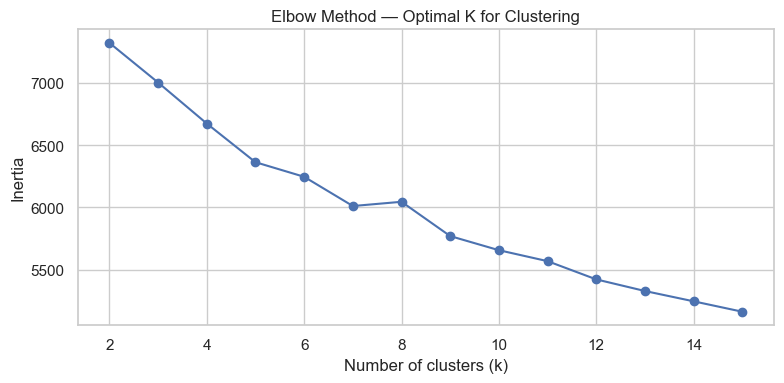

In [12]:
inertias = []
K_range = range(2, 16)

print('Running K-Means for k =', list(K_range), '...')
for k in K_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3)
    km.fit(X_reduced)
    inertias.append(km.inertia_)
    print(f'  k={k}: inertia={km.inertia_:.0f}')

plt.figure(figsize=(8,4))
plt.plot(list(K_range), inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K for Clustering')
plt.tight_layout(); plt.show()


### 2.5.1 Silhouette Score
Measures how similar each item is to its own cluster vs. other clusters. Range [-1, 1] — higher is better.

In [13]:
BEST_K = 8  # Adjust based on elbow plot

km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
labels = km_final.fit_predict(X_reduced)
df['cluster'] = labels

sil_score = silhouette_score(X_reduced, labels, sample_size=2000, random_state=42)
print(f'Silhouette Score (k={BEST_K}): {sil_score:.4f}')
print('Interpretation: >0.25 = reasonable structure, >0.50 = strong structure')


Silhouette Score (k=8): 0.1188
Interpretation: >0.25 = reasonable structure, >0.50 = strong structure


### 2.5.2 Davies-Bouldin Index (DBI)
Measures ratio of within-cluster scatter to between-cluster separation. Lower is better (0 is ideal).

In [14]:
dbi = davies_bouldin_score(X_reduced, labels)
print(f'Davies-Bouldin Index (k={BEST_K}): {dbi:.4f}')
print('Interpretation: Lower = better separated clusters')


Davies-Bouldin Index (k=8): 2.5312
Interpretation: Lower = better separated clusters


### 2.5.3 Calinski-Harabasz Index (CH Index)
Ratio of between-cluster variance to within-cluster variance. Higher is better.

In [15]:
ch_score = calinski_harabasz_score(X_reduced, labels)
print(f'Calinski-Harabasz Index (k={BEST_K}): {ch_score:.2f}')
print('Interpretation: Higher = denser, better-separated clusters')


Calinski-Harabasz Index (k=8): 383.34
Interpretation: Higher = denser, better-separated clusters


### Clustering Metrics Summary

In [16]:
metrics_df = pd.DataFrame([{
    'Metric': 'Silhouette Score',
    'Value': round(sil_score, 4),
    'Better': 'Higher (max 1.0)',
    'Interpretation': 'Cluster cohesion vs separation'
},{
    'Metric': 'Davies-Bouldin Index',
    'Value': round(dbi, 4),
    'Better': 'Lower (min 0.0)',
    'Interpretation': 'Cluster scatter vs distance between clusters'
},{
    'Metric': 'Calinski-Harabasz Index',
    'Value': round(ch_score, 2),
    'Better': 'Higher',
    'Interpretation': 'Between-cluster vs within-cluster variance'
}])
display(metrics_df)


,Metric,Value,Better,Interpretation
0,Silhouette Score,0.1188,Higher (max 1.0),Cluster cohesion vs separation
1,Davies-Bouldin Index,2.5312,Lower (min 0.0),Cluster scatter vs distance between clusters
2,Calinski-Harabasz Index,383.3400,Higher,Between-cluster vs within-cluster variance


### Compare Metrics Across K Values

c:\Users\mrgho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
c:\Users\mrgho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
c:\Users\mrgho\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(
c:\User

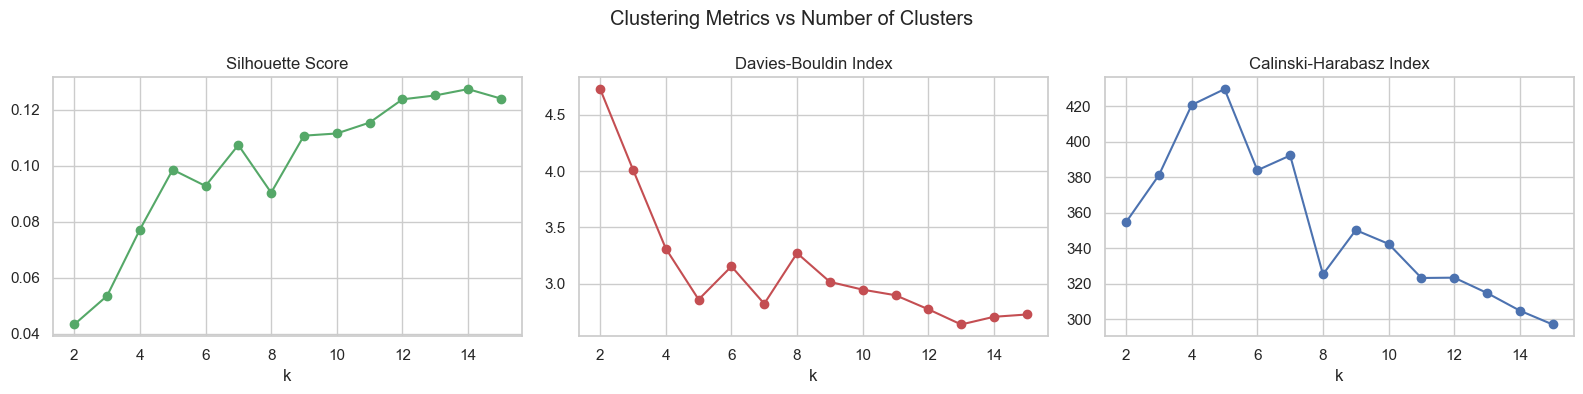

In [17]:
sil_scores, dbi_scores, ch_scores = [], [], []
k_eval_range = range(2, 16)

for k in k_eval_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3)
    lbl = km.fit_predict(X_reduced)
    sil_scores.append(silhouette_score(X_reduced, lbl, sample_size=1500, random_state=42))
    dbi_scores.append(davies_bouldin_score(X_reduced, lbl))
    ch_scores.append(calinski_harabasz_score(X_reduced, lbl))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(list(k_eval_range), sil_scores, 'go-'); axes[0].set_title('Silhouette Score'); axes[0].set_xlabel('k')
axes[1].plot(list(k_eval_range), dbi_scores, 'ro-'); axes[1].set_title('Davies-Bouldin Index'); axes[1].set_xlabel('k')
axes[2].plot(list(k_eval_range), ch_scores, 'bo-'); axes[2].set_title('Calinski-Harabasz Index'); axes[2].set_xlabel('k')
plt.suptitle('Clustering Metrics vs Number of Clusters')
plt.tight_layout(); plt.show()


---
## 3.3 Explainable AI — Clustering

We explain **what each cluster represents** and why the recommendation space is structured the way it is.


### 3.3.1 Cluster Profiling — Mean/Median per Feature
For each cluster, compute the distribution of key features.
**Why:** Tells us if cluster 0 is 'Crime Dramas' and cluster 3 is 'Kids Shows' — validates that TF-IDF has learned meaningful content groups.

In [18]:
cluster_profile = df.groupby('cluster').agg(
    n_items       = ('title', 'count'),
    avg_year      = ('release_year', 'mean'),
    pct_movies    = ('type', lambda x: (x == 'Movie').mean()),
).round(2)

# Top genre per cluster
def top_genre(cluster_df):
    if 'genres' in cluster_df.columns:
        genres = cluster_df['genres'].dropna()
    else:
        genres = cluster_df['listed_in'].dropna().str.split(',').explode().str.strip()
    vc = genres.value_counts() if hasattr(genres.iloc[0], '__len__') else genres.value_counts()
    return vc.index[0] if len(vc) > 0 else 'unknown'

# Explode genres for cluster profiling
if 'genres' in df.columns:
    genre_exploded = df[['cluster','listed_in']].copy()
    genre_exploded['genre'] = df['listed_in'].str.split(',').apply(
        lambda xs: [x.strip() for x in xs] if isinstance(xs, list) else [str(xs)]
    )
    genre_exploded = genre_exploded.explode('genre')
    top_genres_per_cluster = (
        genre_exploded.groupby(['cluster','genre']).size()
                     .reset_index(name='count')
                     .sort_values(['cluster','count'], ascending=[True,False])
                     .groupby('cluster').head(3)
                     .groupby('cluster')['genre'].apply(lambda x: ', '.join(x))
    )
    cluster_profile['top_genres'] = top_genres_per_cluster

display(cluster_profile)


,n_items,avg_year,pct_movies,top_genres
cluster,,,,
0,440,2015.82,0.82,"Stand-Up Comedy, Stand-Up Comedy & Talk Shows,..."
1,1832,2016.71,0.01,"International TV Shows, TV Dramas, Crime TV Shows"
2,831,2010.63,0.87,"Action & Adventure, International Movies, Dramas"
3,3295,2013.08,0.97,"Dramas, International Movies, Comedies"
4,729,2013.97,0.97,"Children & Family Movies, Comedies, Dramas"
5,869,2015.34,0.98,"Documentaries, International Movies, Music & M..."
6,476,2015.79,0.04,"Kids' TV, TV Comedies, British TV Shows"
7,332,2012.97,0.73,"Sci-Fi & Fantasy, Action & Adventure, TV Sci-F..."


### 3.3.2 Boxplots & Radar Charts per Cluster
**Why:** Visualizes how clusters differ across numeric and categorical dimensions.

C:\Users\mrgho\AppData\Local\Temp\ipykernel_11220\4003633227.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster', y='release_year', palette='tab10')


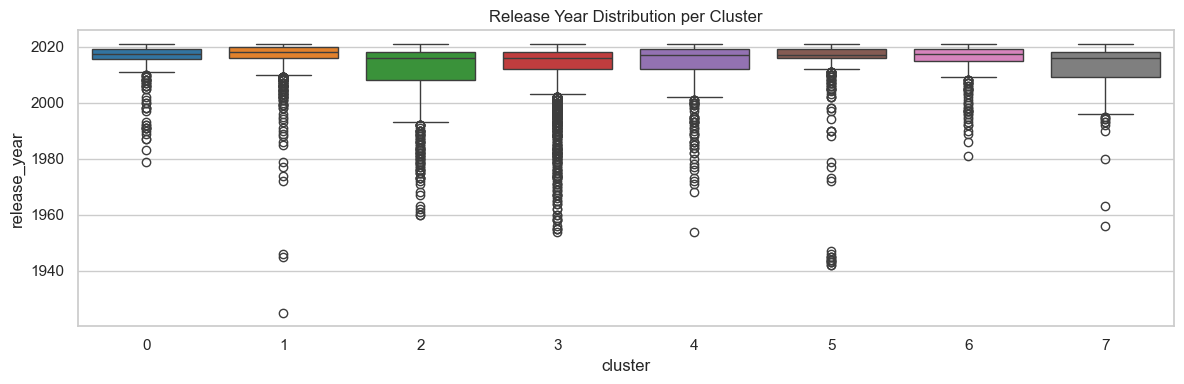

C:\Users\mrgho\AppData\Local\Temp\ipykernel_11220\4003633227.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster', y='duration_value', palette='tab10')


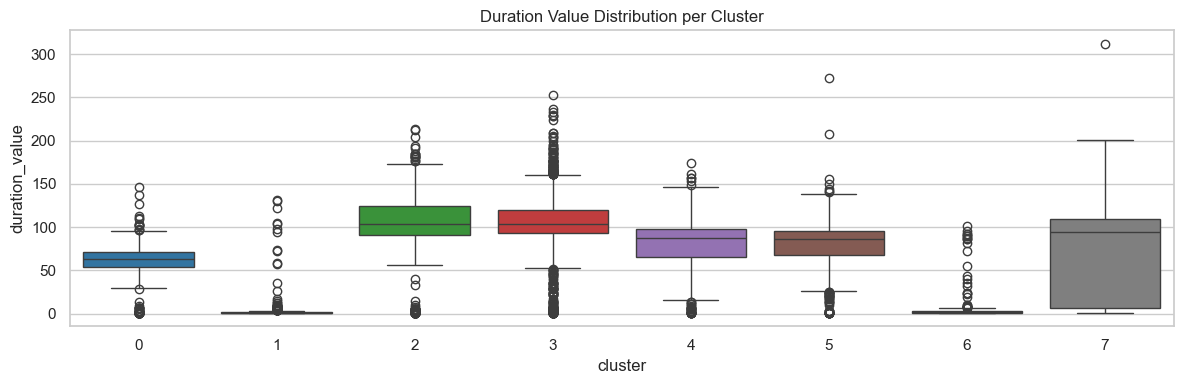

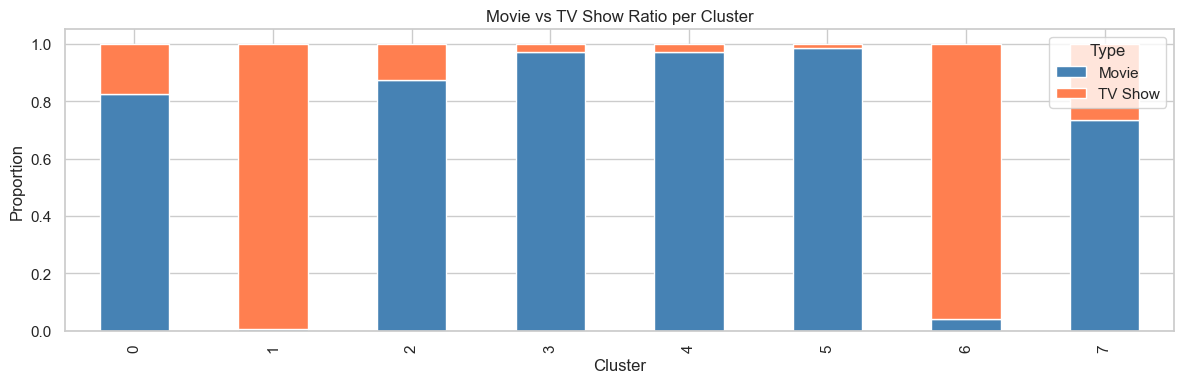

In [19]:
# Boxplot: release_year per cluster
plt.figure(figsize=(12,4))
sns.boxplot(data=df, x='cluster', y='release_year', palette='tab10')
plt.title('Release Year Distribution per Cluster')
plt.tight_layout(); plt.show()

# Boxplot: duration_value per cluster
if 'duration_value' in df.columns:
    plt.figure(figsize=(12,4))
    sns.boxplot(data=df, x='cluster', y='duration_value', palette='tab10')
    plt.title('Duration Value Distribution per Cluster')
    plt.tight_layout(); plt.show()

# Stacked bar: content type ratio per cluster
type_ratio = df.groupby(['cluster','type']).size().unstack(fill_value=0)
type_ratio_pct = type_ratio.div(type_ratio.sum(axis=1), axis=0)
type_ratio_pct.plot(kind='bar', stacked=True, figsize=(12,4),
                   color=['steelblue','coral'])
plt.title('Movie vs TV Show Ratio per Cluster')
plt.xlabel('Cluster'); plt.ylabel('Proportion')
plt.legend(title='Type')
plt.tight_layout(); plt.show()


### Radar Chart per Cluster
**Why:** Compact multi-dimensional view of each cluster's personality.

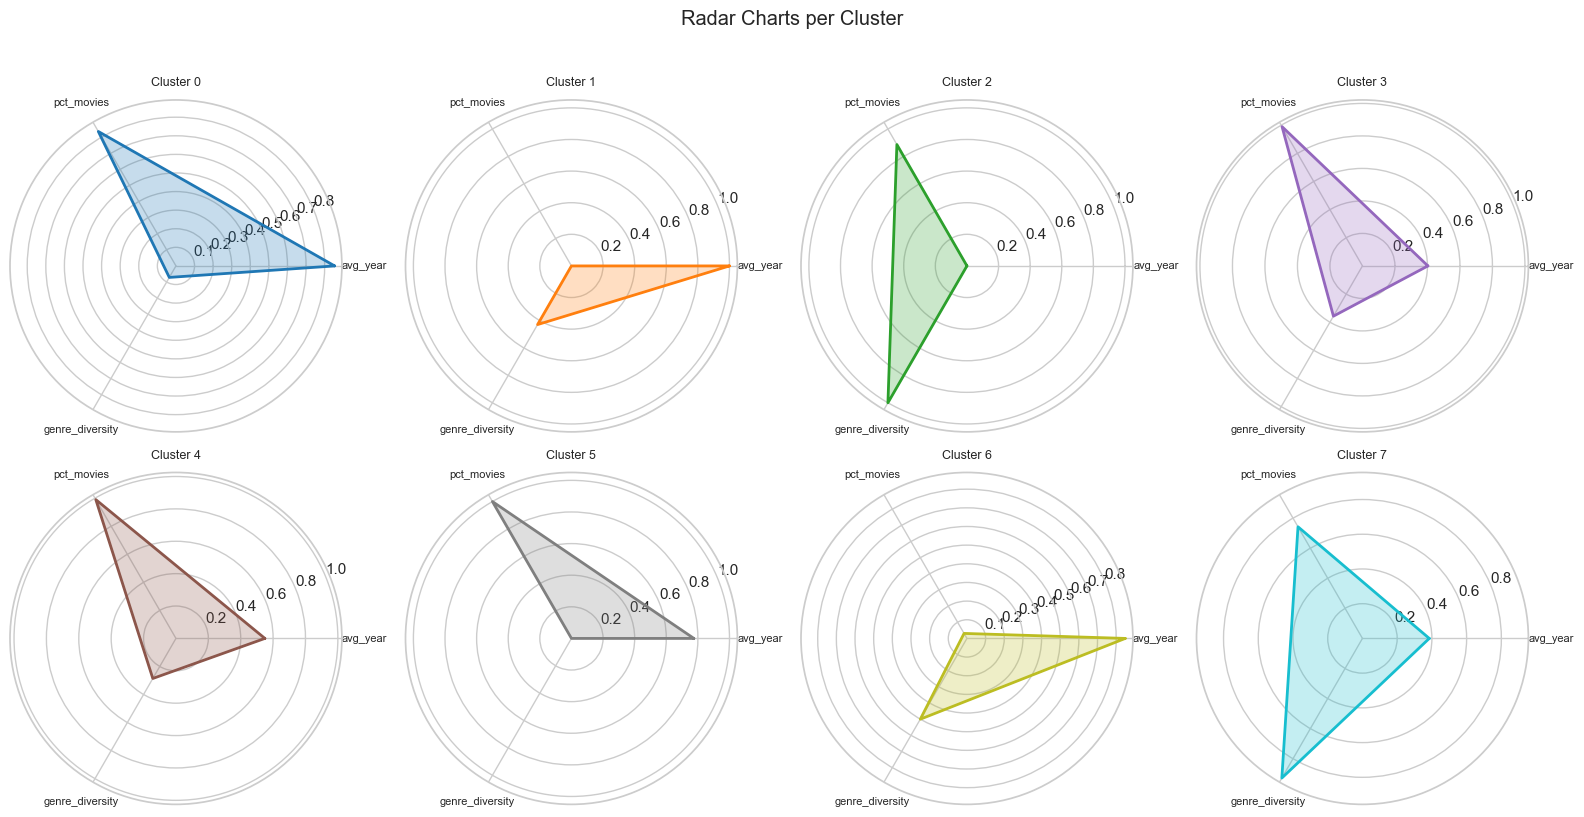

In [20]:
import matplotlib.patches as mpatches

# Normalize cluster profile for radar
radar_cols = ['avg_year', 'pct_movies']
radar_df = cluster_profile[radar_cols].copy()
# Add genre diversity: count of unique genres
genre_div = (
    df.groupby('cluster')['listed_in']
      .apply(lambda s: s.str.split(',').explode().str.strip().nunique())
)
radar_df['genre_diversity'] = genre_div

# Normalize each column to [0,1]
for col in radar_df.columns:
    mn, mx = radar_df[col].min(), radar_df[col].max()
    if mx > mn:
        radar_df[col] = (radar_df[col] - mn) / (mx - mn)

labels = radar_df.columns.tolist()
num_vars = len(labels)
angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, BEST_K//2, figsize=(16, 8), subplot_kw=dict(polar=True))
axes = axes.flatten()
colors = plt.cm.tab10(np.linspace(0, 1, BEST_K))

for i, (cluster_id, row) in enumerate(radar_df.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax = axes[i]
    ax.plot(angles, values, color=colors[i], linewidth=2)
    ax.fill(angles, values, color=colors[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=8)
    ax.set_title(f'Cluster {cluster_id}', size=9, pad=10)

plt.suptitle('Radar Charts per Cluster', y=1.02)
plt.tight_layout(); plt.show()


### 3.3.3 Silhouette Analysis — Per Point & Per Cluster
**Why:** Identifies which clusters are well-defined and which items are borderline between clusters.

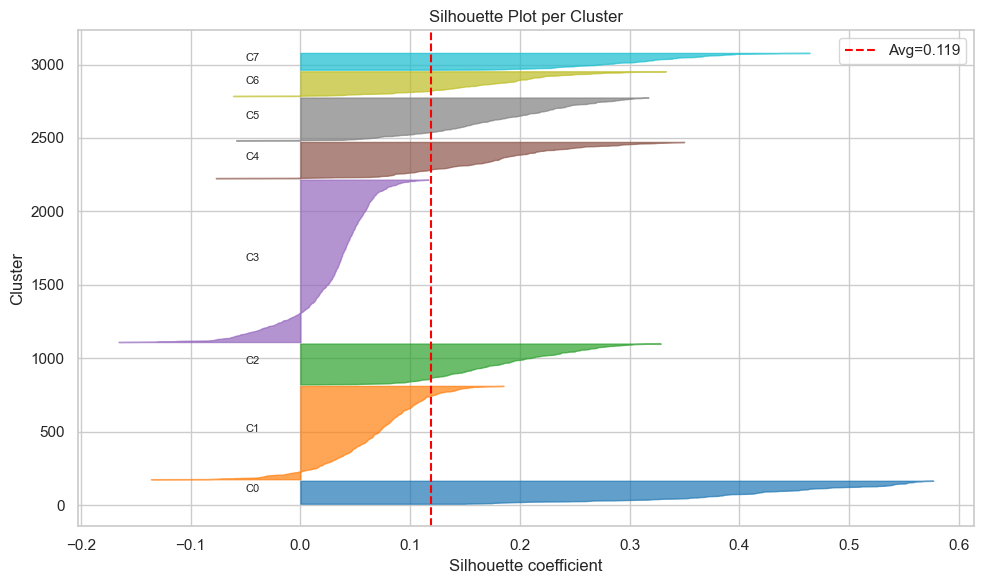

Average silhouette per cluster:


,silhouette
0,0.4118
1,0.0656
2,0.1848
3,0.0283
4,0.1762
5,0.1798
6,0.1692
7,0.3049


In [21]:
from sklearn.metrics import silhouette_samples

# Redefine labels as cluster labels, since it was overwritten in a later cell
labels = km_final.labels_

# Sample for speed
SAMPLE_SIZE = min(3000, len(df))
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(df), SAMPLE_SIZE, replace=False)

X_sample = X_reduced[sample_idx]
labels_sample = labels[sample_idx]

sil_values = silhouette_samples(X_sample, labels_sample)

# Plot silhouette per cluster
fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, BEST_K))

for i in range(BEST_K):
    cluster_sil = np.sort(sil_values[labels_sample == i])
    y_upper = y_lower + len(cluster_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + len(cluster_sil)/2, f'C{i}', fontsize=8)
    y_lower = y_upper + 10

ax.axvline(x=sil_score, color='red', linestyle='--', label=f'Avg={sil_score:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot per Cluster')
ax.legend(); plt.tight_layout(); plt.show()

# Per-cluster average
sil_per_cluster = pd.Series(sil_values).groupby(labels_sample).mean().round(4)
print('Average silhouette per cluster:')
display(sil_per_cluster.rename('silhouette').to_frame())


### 3.3.4 Feature Contribution per Cluster
Top TF-IDF terms driving each cluster — explains **what makes each cluster different**.
**Why:** Validates that the model has learned genre/theme groups, not random splits.

In [22]:
# Get TF-IDF feature names
feature_names = np.array(tfidf.get_feature_names_out())

# For each cluster, find the centroid in TF-IDF space
# (We reconstruct centroid from SVD by projecting back)
print('Top 10 terms driving each cluster:\n')
for cluster_id in range(BEST_K):
    cluster_indices = np.where(labels == cluster_id)[0]
    cluster_matrix = X[cluster_indices]  # Original TF-IDF (not reduced)
    centroid = cluster_matrix.mean(axis=0).A1  # Dense vector
    top_idx = centroid.argsort()[::-1][:10]
    top_terms = feature_names[top_idx]
    top_scores = centroid[top_idx]
    print(f'Cluster {cluster_id} ({len(cluster_indices)} items):')
    for term, score in zip(top_terms, top_scores):
        print(f'  {term:<30} {score:.4f}')
    print()


Top 10 terms driving each cluster:

Cluster 0 (440 items):
  stand                          0.1397
  comedy                         0.1346
  comedian                       0.0498
  special                        0.0470
  comic                          0.0313
  talk                           0.0292
  ma                             0.0256
  stage                          0.0230
  movie                          0.0179
  takes                          0.0169

Cluster 1 (1832 items):
  shows                          0.0863
  unknown                        0.0538
  international                  0.0391
  docuseries                     0.0312
  crime                          0.0304
  series                         0.0260
  reality                        0.0230
  dramas                         0.0217
  romantic                       0.0210
  british                        0.0183

Cluster 2 (831 items):
  action                         0.0954
  adventure                      0.0936
  movies    

### 3.3.4b Visualize Top Terms per Cluster

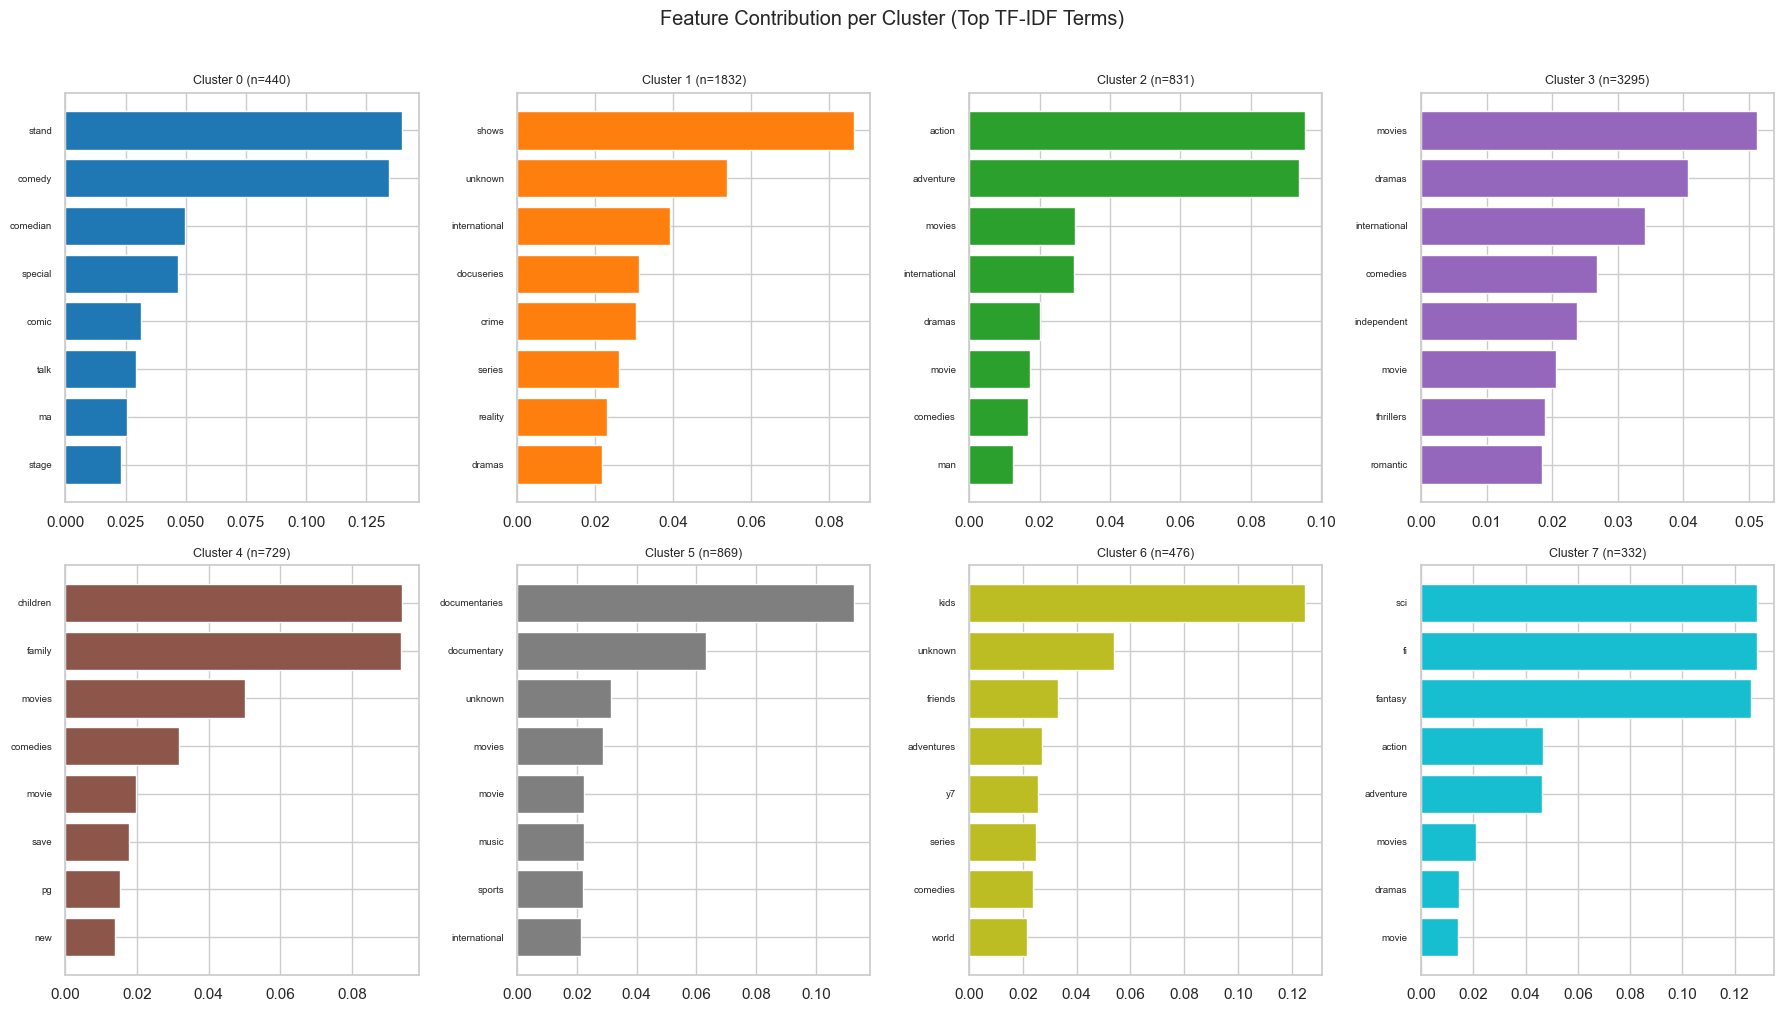

In [23]:
fig, axes = plt.subplots(2, BEST_K//2, figsize=(18, 10))
axes = axes.flatten()

for cluster_id in range(BEST_K):
    cluster_indices = np.where(labels == cluster_id)[0]
    centroid = X[cluster_indices].mean(axis=0).A1
    top_idx = centroid.argsort()[::-1][:8]
    top_terms = feature_names[top_idx]
    top_scores = centroid[top_idx]

    axes[cluster_id].barh(top_terms[::-1], top_scores[::-1], color=colors[cluster_id])
    n = len(cluster_indices)
    axes[cluster_id].set_title(f'Cluster {cluster_id} (n={n})', fontsize=9)
    axes[cluster_id].tick_params(axis='y', labelsize=7)

plt.suptitle('Feature Contribution per Cluster (Top TF-IDF Terms)', y=1.01)
plt.tight_layout(); plt.show()


### Recommendation Explainability — Why Was X Recommended?

In [24]:
def explain(seed_title, rec_title, year=None):
    q_idx = _resolve_index(seed_title, year)
    r_idx = _resolve_index(rec_title)
    q_row, r_row = df.loc[q_idx], df.loc[r_idx]
    text_s  = cosine_similarity(X[q_idx:q_idx+1], X[r_idx:r_idx+1]).ravel()[0]
    genre_s = jaccard(genre_set(q_row['listed_in']), genre_set(r_row['listed_in']))
    year_s  = year_closeness(q_row['release_year'], r_row['release_year'])
    same_cluster = df.loc[q_idx,'cluster'] == df.loc[r_idx,'cluster']
    print('='*65)
    print(f'Why {r_row["title"]!r} was recommended for {q_row["title"]!r}')
    print('='*65)
    print(f'Text similarity  : {text_s:.3f}')
    print(f'Genre overlap    : {genre_s:.3f}')
    print(f'Year closeness   : {year_s:.3f}')
    print(f'Same cluster     : {same_cluster} (Cluster {df.loc[q_idx,"cluster"]})')
    print(f'Shared genres    : {sorted(genre_set(q_row["listed_in"]) & genre_set(r_row["listed_in"])) or "—"}')
    print(f'Seed description : {str(q_row["description"])[:140]}...')
    print(f'Rec  description : {str(r_row["description"])[:140]}...')

# Example
results = recommend("peaky blinders", top_n=5)
display(results)
print()
explain("peaky blinders", results.loc[0,'title'])


,title,type,release_year,rating,listed_in,text_sim,genre_overlap,year_close,final_score,match_quality
0,The Great Train Robbery,TV Show,2013,NR,"British TV Shows, Crime TV Shows, Internationa...",0.128175,1.0,0.548774,0.845011,Excellent
1,The Frankenstein Chronicles,TV Show,2017,TV-MA,"British TV Shows, Crime TV Shows, Internationa...",0.114979,1.0,0.818716,0.816396,Excellent
2,Giri / Haji,TV Show,2019,TV-MA,"British TV Shows, Crime TV Shows, Internationa...",0.104677,1.0,1.000000,0.791112,Excellent
3,Criminal: Spain,TV Show,2019,TV-MA,"British TV Shows, Crime TV Shows, Internationa...",0.089227,1.0,1.000000,0.726005,Excellent
4,Jonathan Strange & Mr Norrell,TV Show,2015,TV-14,"British TV Shows, TV Dramas, TV Sci-Fi & Fantasy",0.139413,0.2,0.670293,0.704520,Excellent



Why 'The Great Train Robbery' was recommended for 'Peaky Blinders'
Text similarity  : 0.128
Genre overlap    : 1.000
Year closeness   : 0.549
Same cluster     : True (Cluster 1)
Shared genres    : ['british tv shows', 'crime tv shows', 'international tv shows']
Seed description : A notorious gang in 1919 Birmingham, England, is led by the fierce Tommy Shelby, a crime boss set on moving up in the world no matter the co...
Rec  description : This two-part tale delivers the true story of the Great Train Robbery of 1963, the biggest one in England's history....


### Summary

In [25]:
print('=== Notebook 2 Summary ===')
print(f'Dataset      : {len(df)} items')
print(f'TF-IDF shape : {X.shape}')
print(f'SVD shape    : {X_reduced.shape}')
print(f'Clusters (k) : {BEST_K}')
print(f'Silhouette   : {sil_score:.4f}')
print(f'DBI          : {dbi:.4f}')
print(f'CH Index     : {ch_score:.2f}')
print()
print('All assignment sections covered:')
print('  2.1 Pipeline Construction         [done]')
print('  2.2 Model Training & Hyperparams  [done]')
print('  2.5 Clustering Evaluation         [done]')
print('  3.3 XAI for Clustering            [done]')


=== Notebook 2 Summary ===
Dataset      : 8804 items
TF-IDF shape : (8804, 20000)
SVD shape    : (8804, 50)
Clusters (k) : 8
Silhouette   : 0.1188
DBI          : 2.5312
CH Index     : 383.34

All assignment sections covered:
  2.1 Pipeline Construction         [done]
  2.2 Model Training & Hyperparams  [done]
  2.5 Clustering Evaluation         [done]
  3.3 XAI for Clustering            [done]
